<>:27: SyntaxWarning: invalid escape sequence '\o'
<>:27: SyntaxWarning: invalid escape sequence '\o'
C:\Users\Gabriel\AppData\Local\Temp\ipykernel_29256\2588469220.py:27: SyntaxWarning: invalid escape sequence '\o'
  plt.xlabel('$\omega$ (rad/sec)')
C:\Users\Gabriel\anaconda3\Lib\site-packages\scipy\signal\_ltisys.py:600: BadCoefficients: Badly conditioned filter coefficients (numerator): the results may be meaningless
  self.num, self.den = normalize(*system)


Text(0.5, 1.0, 'Laplace Bode Comp')

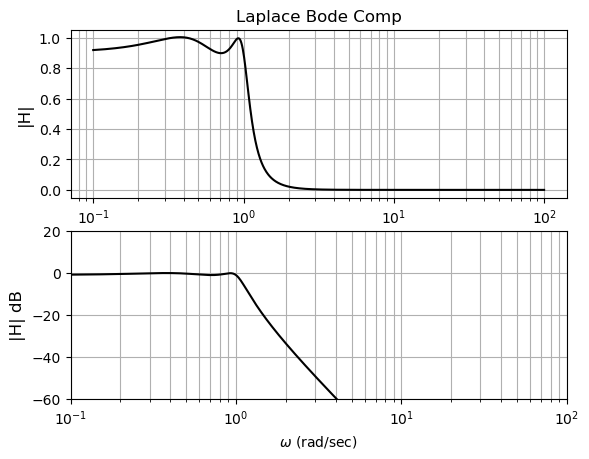

In [1]:
""" Laplace Bode Comp """

import matplotlib.pyplot as plt
import numpy as np
from scipy import signal as sig
from math import pi, exp, cos, sin, log, sqrt
from control import margin
from control import tf

num = [0,0,0,0,0.258]
den = [1,0.9826,1.4823,0.77376,0.284856]

w = np.linspace(0.1,100,num=10000)
system = sig.lti(num,den)
w, Hmag, Hphase = sig.bode(system,w)
gm, pm, wg, wp = margin(Hmag,Hphase,w)

plt.subplot(212)
plt.semilogx(w,Hmag,'k')
plt.axis([ .1, 1e2, -60, 20])
plt.ylabel('|H| dB',size = 12)
plt.grid(which='both')
plt.xlabel('$\omega$ (rad/sec)')

plt.subplot(211)
plt.semilogx(w,10**(0.05*Hmag),'k')
plt.ylabel('|H|',size = 12)
plt.grid(which='both')
plt.title('Laplace Bode Comp')

<>:78: SyntaxWarning: invalid escape sequence '\o'
<>:81: SyntaxWarning: invalid escape sequence '\o'
<>:102: SyntaxWarning: invalid escape sequence '\o'
<>:114: SyntaxWarning: invalid escape sequence '\o'
<>:116: SyntaxWarning: invalid escape sequence '\o'
<>:117: SyntaxWarning: invalid escape sequence '\o'
<>:78: SyntaxWarning: invalid escape sequence '\o'
<>:81: SyntaxWarning: invalid escape sequence '\o'
<>:102: SyntaxWarning: invalid escape sequence '\o'
<>:114: SyntaxWarning: invalid escape sequence '\o'
<>:116: SyntaxWarning: invalid escape sequence '\o'
<>:117: SyntaxWarning: invalid escape sequence '\o'
C:\Users\Gabriel\AppData\Local\Temp\ipykernel_29256\2967452454.py:78: SyntaxWarning: invalid escape sequence '\o'
  plt.text(2.5,-25,'$\omega$p = {}'.format(round(omega0,2)),fontsize=12)
C:\Users\Gabriel\AppData\Local\Temp\ipykernel_29256\2967452454.py:81: SyntaxWarning: invalid escape sequence '\o'
  plt.text(11,-25,'$\omega$s = {}'.format(round(omega1,2)),fontsize=12)
C:\User

A: c1A =  0.00249  d1A =  -1.93019  d0A =  0.93295
B: c1B =  0.00984 d1B =  -1.96174  d0B =  0.97155


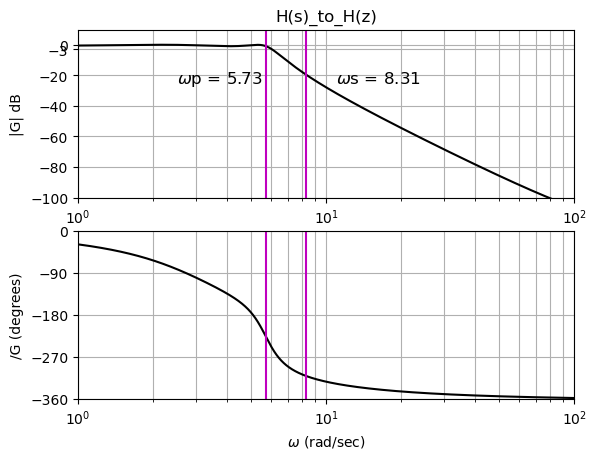

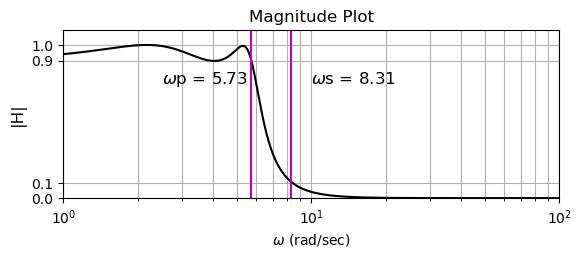

In [8]:
""" H(s)_to_H(z).py """

import matplotlib.pyplot as plt
import numpy as np
from scipy import signal as sig
from math import pi, exp, cos, sin, log, sqrt
from control import margin
from control import tf
import cmath

NN = 100000
phi = np.linspace(0,2*pi,NN)

dt = .1
z = np.zeros(NN, dtype = complex)
H = np.zeros(NN, dtype = complex)
HA = np.zeros(NN, dtype = complex)
HB = np.zeros(NN, dtype = complex)

a0 = 0.258
a1 = 0
b0 = 0.286
b1 = 0.694

alpha = b1/2
omega = sqrt(b0 - (b1/2)**2)
K1A = (a0 - a1*alpha)/omega
exaTA = exp(-alpha*dt)
omegTA = omega*dt
c1A = dt*K1A*exaTA*sin(omegTA)
d1A = -2*exaTA*cos(omegTA)
d0A = exaTA**2
print("A: c1A = ",round(c1A,5)," d1A = ",round(d1A,5),
        " d0A = ",round(d0A,5) )

a0 = 1
a1 = 0
b0 = 0.996
b1 = 0.2886

alpha = b1/2
omega = sqrt(b0 - (b1/2)**2)
K1B = (a0 - a1*alpha)/omega
exaTB = exp(-alpha*dt)
omegTB = omega*dt
c1B = dt*K1B*exaTB*sin(omegTB)
d1B = -2*exaTB*cos(omegTB)
d0B = exaTB**2
print("B: c1B = ",round(c1B,5),
        "d1B = ",round(d1B,5)," d0B = ",round(d0B,5) )

for n in range(0,NN):
    z = cmath.exp(1j*phi[n])
    
    num = c1A*z
    den = z**2 + d1A*z + d0A
    HA[n] = (num/den)
    
    num = c1B*z
    den = z**2 + d1B*z + d0B
    HB[n] = (num/den)
    
    H[n] = HA[n]*HB[n] 
    
omega0 = (1*dt*180/pi)
omega1 = (1.45*dt*180/pi)

plt.figure()
plt.subplot(211)
plt.title('H(s)_to_H(z)')
plt.semilogx((180/pi)*phi,20*np.log10(H),'k')
plt.axis([1,100, -100, 10])
plt.yticks([0,-3,-20,-40,-60,-80,-100])
plt.ylabel('|G| dB'),-10
plt.axvline(omega0,color='m')
plt.text(2.5,-25,'$\omega$p = {}'.format(round(omega0,2)),fontsize=12)
plt.axvline(omega1,color='m')
plt.text(11,-25,'$\omega$s = {}'.format(round(omega1,2)),fontsize=12)
plt.grid(which='both')

aaa = np.angle(H)
for n in range(NN):
    if aaa[n] > 0:
        aaa[n] = aaa[n] - 2*pi
    
plt.subplot(212)
plt.semilogx((180/pi)*phi,(180/pi)*aaa,'k')
plt.ylabel('/G (degrees)')
plt.axis([1,100, -360,0])
plt.yticks([-360,-270,-180,-90,0])
plt.axvline(omega0,color='m')
plt.axvline(omega1,color='m')
plt.grid(which='both')
plt.xlabel('$\omega$ (rad/sec)')
plt.show()

plt.figure()
plt.subplot(211)
plt.semilogx((180/pi)*phi,abs(H),'k')
plt.ylabel('|H|',size = 12)
plt.grid(which='both')
plt.title('Magnitude Plot')
plt.axis([1,100, 0, 1.1])
plt.yticks([0,0.1,0.9,1])
plt.axvline(omega0,color='m')
plt.text(2.5,.75,'$\omega$p = {}'.format(round(omega0,2)),fontsize=12)
plt.axvline(omega1,color='m')
plt.text(10,.75,'$\omega$s = {}'.format(round(omega1,2)),fontsize=12)
plt.xlabel('$\omega$ (rad/sec)')
plt.xticks([1,10,100])
plt.show()

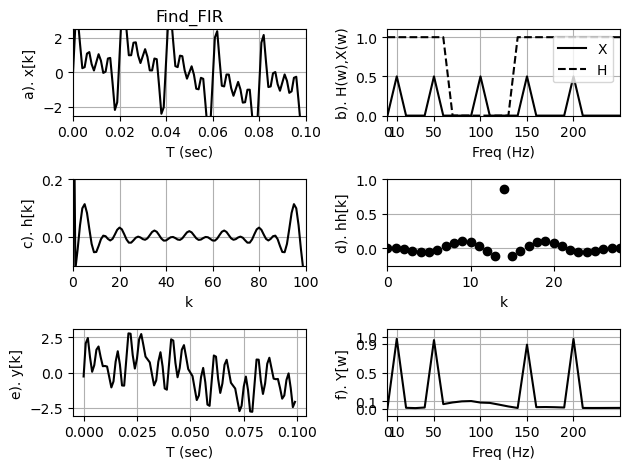

In [10]:
""" Find_FIR_ """

import matplotlib.pyplot as plt
import numpy as np
from scipy import signal as sig
from math import pi, exp, cos, sin, log, sqrt

NN = 100
N2 = int(NN/2)
x = np.zeros(NN)
y = np.zeros(NN)

dt = .001
TT = np.linspace(0,dt*(NN-1),NN)
DF = 1/(dt*NN)
FF = np.linspace(0,DF*(NN-1),NN)

""" Create the time-domain input """

f1 = 10
f2 = 50
f3 = 100
f4 = 150
f5 = 200
freq1 = 2*pi*f1
freq2 = 2*pi*f2
freq3 = 2*pi*f3
freq4 = 2*pi*f4
freq5 = 2*pi*f5

x = np.sin(freq1*TT) + np.sin(freq2*TT) + np.sin(freq3*TT) + np.sin(freq4*TT) + np.sin(freq5*TT)

plt.subplot(321)
plt.plot(TT,x,'k')
plt.axis([0,NN*dt,-2.5,2.5])
plt.title('Find_FIR')
plt.ylabel('a). x[k]')
plt.xlabel('T (sec)')
plt.grid()

X = (1/NN)*np.fft.fft(x)

""" Create the filter """
H = np.zeros(NN)

""" Rectangular LPF """
for n in range(7):
    H[n] = 1

""" Rectangular HPF """
for n in range(14,N2+2):
    H[n] = 1

""" Reflect the positive frequencies to the right side """
for n in range(1,N2-1):
    H[NN-n] = H[n]

Y = H*X

plt.subplot(322)
plt.plot(FF,abs(X),'k',label='X')
plt.plot(FF,H,'k--',label='H')
plt.legend(loc='upper right')
plt.ylabel('b). H(w),X(w)')
plt.xlabel('Freq (Hz)')
plt.grid()
plt.axis([0,250,0,1.1])
plt.xticks([0,10,50,100,150,200])

h = np.fft.ifft(H)

plt.subplot(323)
plt.plot(h.real,'k')
plt.xlabel('k')
plt.ylabel('c). h[k]')
plt.grid()
plt.axis([0,NN,-.1,.2])

M = 14
hh = np.zeros(NN)

""" Move the filter to the left side """
for n in range(M):
    hh[n+M] = h[n].real
    hh[M-n] = hh[M+n]

plt.subplot(324)
plt.plot(hh,'ok')
plt.axis([0 ,2*M,-.25,1])
plt.xlabel('k')
plt.ylabel('d). hh[k]')
plt.grid()

""" Convolve hh and x """

yy=np.convolve(hh,x)

y = np.zeros(NN)
for n in range(NN):
    y[n] = yy[n+M]

plt.subplot(325)
plt.plot(TT,y,'k')
4
plt.ylabel('e). y[k]')
plt.xlabel('T (sec)')
plt.grid()

Y = (1/NN)*np.fft.fft(y)

plt.subplot(326)
plt.plot(FF,2*abs(Y),'k')
plt.ylabel('f). Y[w]')
plt.xlabel('Freq (Hz)')
plt.grid()
plt.xticks([0,10,50,100,150,200])
plt.yticks([0,0.1,0.5,0.9,1])
plt.axis([0,250,-.1,1.1])
plt.tight_layout()
plt.show()